<h1 align="center">SWDB Problem Set: Becoming a Data Detective</h1>
<h3 align="center">From someone else's figure to your own analysis</h3>
<p align="center"><b>SOLUTIONS</b> &mdash; worked on the V1 Deep Dive dataset</p>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>How this problem set works</h2>

In the today's tutorial you explored a dataset and made figures. Those figures are now posted on Slack.

**Your starting point is one of your classmates' figures.** Pick any figure from the channel, along
with the dataset it came from &mdash; ideally one you did *not* work on this morning.

The task for this problem set is to reproduce your classmate's figure, then dive deeper into the dataset 
to investigate what conditions are available, explore activity patterns across trials and across cells,
and consider how your analysis decisions affect your interpretation of the data. 

| Part | Task |
| --- | --- |
| 1 | Load their dataset and find the pieces the figure needs |
| 2 | Reproduce the figure, and interrogate what it shows |
| 3 | Align activity to event onsets: raster and PSTH |
| 4 | Signal and noise correlations, and whether to trust them |

You already have the data-access skills for Part 1 from this morning's tutorial. This problem set is
about what comes after loading: **shaping data, and checking whether the result means anything.**

**Deliverable:** a short README naming the figure and dataset you chose, the decisions you made at
each step, and an honest assessment of what your numbers do and do not support.

<b>Every dataset is different, and the notebook does not know which one you picked.</b> The code
cells are prompts, not templates &mdash; you write what goes in them, using the access patterns from
this morning. Only a few things are given: the imports, and two helper functions from the tutorial.

There are several important differences to look out for across the datasets in this workshop:

- **Recording modality** &mdash; a continuous calcium signal in some, discrete spike times in
  others. Spikes need binning before anything here applies.
- **Sampling rate** &mdash; from a few Hz to tens of kHz, which determines what timing you can resolve.
- **Number of neurons** &mdash; tens to thousands, which changes what is tractable in your analysis.
- **Stimulus structure** &mdash; many conditions with few repeats, few conditions with many, or no
  sensory stimulus at all.
- **What was recorded alongside** &mdash; running, licking, pupil, reward; some datasets have all of
  it, some none.
- **Where things live in the file** &mdash; container and column names differ, and so does which
  container holds the stimulus or trials table.

None of that is written on the outside of the file. **You have to look.** Part of each prompt is
deciding whether the analysis it asks for even applies to your dataset &mdash; and saying so when it
does not.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>Taking it slow: Analysis step by step</h2>

In the age of LLMs, you can now generate an analysis faster than you can check one. Ask an LLM for a correlation matrix
and you will have one in thirty seconds, beautifully formatted, with a colorbar.

The problem is that a result computed on four trials can look exactly like a result computed on four
hundred. A bug can look exactly like a finding. A correlation computed in a window where nothing
happened can look exactly like a real effect.

This is also true of analyses performed by other humans, such as figures in a paper, or the plot generated by your colleague in today's tutorial. 
To truly understand any given result, you need to consider the essential features of the data, 
how it was transformed, how it is being displayed, and the assumptions that were made. 
This is important to consider as you work through your own analysis as well. 

So the questions to keep asking are:

- **What is actually in this data file?** Not what you assume &mdash; what is there.
- **Does this dataset support the question I am asking?** 
- **How is the data being transformed?** Plot the data after each step.
- **What would make this result wrong?** Name it before you see the answer.

</div>

---

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pynwb
from scipy import stats

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)

data_dir = '/data'

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 1: Load the dataset and find the pieces you need</h1>

Same access pattern as this morning: find your dataset's mount under <code>/data</code>, locate a
session's NWB file, then dot and bracket notation into the containers.

**Your classmate's figure tells you what to look for.** Before you open anything, list the pieces the
figure needs &mdash; neural activity, plus whatever else it plots: a behavioral trace, epoch
boundaries, trial times, stimulus identity.

</div>

In [2]:
# List the datasets mounted under /data.

for mount in sorted(os.listdir(data_dir)):
    print(mount)

409828_V1DD_Filtered
416296_V1DD_Filtered
427836_V1DD_Filtered
438833_V1DD_Filtered
Neuropixels_Opto_ecephys_nwb_combined
Visual-Learning-SWDB
brain-computer-interface-v2
dynamicrouting_datacube
metadata
visual_coding_neuropixels
visual_coding_ophys


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Which session does your classmate's figure come from? Use the table to find it
&mdash; subject, session type, date &mdash; and say what you filtered on.

Look at what the table offers before you filter. How many subjects, how many session types, how many
sessions each? That inventory is the first thing you know about the dataset.

**What are the features of your selected sesssion?** Is it from a specific recording location or does it utilize a particular stimulus set?

Ask what kind of neurons you are recording from in the selected session. This is not a detail &mdash; it decides
what your population average means. Check the transgenic line, the virus, and any other metadata
describing what was labeled. 

The recording modality also has important implications: 

- **Imaging.** You see only the cells expressing the calcium indicator. A pan-excitatory driver
  gives you a very different population from an interneuron-specific one, and "population activity"
  in each case means something different.
- **Electrophysiology.** A probe records whatever is near it, so the recording is not cell-type
  specific by default. But a line or virus may still be present for **optotagging** &mdash; light
  activation used to identify a targeted cell type among the recorded units. If so, there may be a
  column marking which units were tagged.

Write down what is labeled and recorded in your session, and say what population your averages are actually
averaging over. 

</div>

In [3]:
# read your dataset's metadata CSV from /code/metadata and look at what it
# offers: how many subjects, how many session types, how many sessions each.

metadata = pd.read_csv(os.path.join(data_dir, 'metadata', 'V1DD_metadata.csv'))

print('shape of metadata table:', metadata.shape)
print('columns in metadata table:', metadata.columns.tolist())

metadata.head()

shape of metadata table: (98, 17)
columns in metadata table: ['project_name', '_id', 'name', 'subject_id', 'golden_mouse', 'genotype', 'date_of_birth', 'age', 'sex', 'modality', 'session_date', 'session_start_time', 'session_end_time', 'column', 'volume', 'depth', 'targeted_structure']


,project_name,_id,name,subject_id,golden_mouse,genotype,date_of_birth,age,sex,modality,session_date,session_start_time,session_end_time,column,volume,depth,targeted_structure
0,V1 Deep Dive,5b6b926a-0771-4664-8053-c52fa0e56189,409828_2018-12-12_12-24-18_filtered_2026-04-09...,409828,True,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai94(TITL-G...,2018-07-03,162,Male,"['Planar optical physiology', 'Behavior videos']",2018-12-12,12:24:18.963730,13:24:27.772570,1,1,"[np.int64(130), np.int64(114), np.int64(98), n...",VISp
1,V1 Deep Dive,88412a4c-b448-4efb-9825-d785bd5b56ba,409828_2018-12-13_13-21-39_filtered_2026-04-09...,409828,True,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai94(TITL-G...,2018-07-03,163,Male,"['Planar optical physiology', 'Behavior videos']",2018-12-13,13:21:39.888000,14:21:12.698880,1,2,"[np.int64(226), np.int64(210), np.int64(194), ...",VISp
2,V1 Deep Dive,dac12127-2aed-4392-ae2f-4a57e1bf85e5,409828_2018-12-13_15-10-05_filtered_2026-04-09...,409828,True,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai94(TITL-G...,2018-07-03,163,Male,"['Planar optical physiology', 'Behavior videos']",2018-12-13,15:10:05.562960,16:09:36.222020,1,3,"[np.int64(322), np.int64(306), np.int64(290), ...",VISp
3,V1 Deep Dive,34d05e9e-ee69-412b-b98d-47dd9d79082e,409828_2018-12-14_13-14-42_filtered_2026-04-09...,409828,True,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai94(TITL-G...,2018-07-03,164,Male,"['Planar optical physiology', 'Behavior videos']",2018-12-14,13:14:42.634500,14:15:00.029230,1,4,"[np.int64(418), np.int64(402), np.int64(386), ...",VISp
4,V1 Deep Dive,925bfce3-6324-40bc-822a-7e0206717880,409828_2018-12-14_14-47-35_filtered_2026-04-09...,409828,True,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai94(TITL-G...,2018-07-03,164,Male,"['Planar optical physiology', 'Behavior videos']",2018-12-14,14:47:35.097180,15:46:50.098970,1,5,"[np.int64(514), np.int64(498), np.int64(482), ...",VISp


In [4]:
# Inventory the metadata table - how many subjects, sessions, session_types

print('subjects:', metadata.subject_id.nunique())
print('sessions:', len(metadata))
print('\nsessions per subject:')
print(metadata.subject_id.value_counts().to_string())

# There is no session_type column in this dataset. A V1DD session is identified
# by subject, cortical column, and imaging volume instead -- each volume is a set
# of planes imaged at different depths in the same column.
print('\ncolumns imaged:', sorted(metadata.column.unique()))
print('volumes per column:', metadata.groupby('column').volume.nunique().to_dict())

subjects: 4
sessions: 98

sessions per subject:
subject_id
416296    25
438833    25
409828    24
427836    24

columns imaged: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
volumes per column: {1: 5, 2: 5, 3: 5, 4: 5, 5: 5}


In [5]:
# Filter the table to the session behind your figure, take one row as
# `session`, and say what you filtered on.
# Which columns identify a session in your dataset -- subject, session type, date?

# The example figure is a session overview -- running speed and population mean
# dF/F with the stimulus blocks shaded behind them. Any V1DD session supports it,
# so we filter on golden_mouse: those subjects were imaged over many sessions
# across several columns and volumes, which makes them the best documented.
candidates = metadata[metadata.golden_mouse == True]
print(f'filtered on golden_mouse: {len(candidates)} session(s)')

session = candidates.iloc[5]
print('selected:', session['name'])

filtered on golden_mouse: 24 session(s)
selected: 409828_2018-11-06_14-02-59_filtered_2026-04-09_04-59-00


In [6]:
# examine the column values of the session you selected
# what is the session type, genotype, the targeted structure, etc. 

# Slc17a7-IRES2-Cre;Camk2a-tTA;Ai94 is a pan-excitatory driver line expressing
# GCaMP6s, so every population average below is an average over excitatory
# neurons in V1 -- not over all neurons, and with no interneurons in it at all.
session

project_name                                               V1 Deep Dive
_id                                052a1270-3807-4044-9a2f-9719048db109
name                  409828_2018-11-06_14-02-59_filtered_2026-04-09...
subject_id                                                       409828
golden_mouse                                                       True
genotype              Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai94(TITL-G...
date_of_birth                                                2018-07-03
age                                                                 126
sex                                                                Male
modality               ['Planar optical physiology', 'Behavior videos']
session_date                                                 2018-11-06
session_start_time                                      14:02:59.889330
session_end_time                                        15:02:13.545940
column                                                          

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

<b>Now build the path and load the data.</b> The metadata table's <code>name</code> column is normally the session's
folder name inside the mount - identify the relevant asset from the list above and grab the relevant folder from within it. 
Inside that folder sits one NWB store &mdash; either a single <code>.nwb</code> file (HDF5) or a <i>directory</i>
(zarr).

</div>


In [7]:
# set `dataset_dir` to the mount holding your dataset (one of the names
# printed above), then join it with your session's folder name to get `session_dir`.

# The mount is per SUBJECT in this dataset -- there is no single V1DD mount.
dataset_dir = os.path.join(data_dir, str(session.subject_id) + '_V1DD_Filtered')
session_dir = os.path.join(dataset_dir, session['name'])

# One session directory holds one NWB store. Match on 'nwb' in the name to catch
# both forms -- a .nwb file and a zarr directory -- but exclude the sidecar
# 'nwb_contents.json' that ships next to the store.
nwb_file = [path for path in os.listdir(session_dir)
            if 'nwb' in path and not path.endswith('.json')]
assert len(nwb_file) == 1, f'expected one NWB store, found {len(nwb_file)}'

nwb_path = os.path.join(session_dir, nwb_file[0])
print(nwb_path)

/data/409828_V1DD_Filtered/409828_2018-11-06_14-02-59_filtered_2026-04-09_04-59-00/409828_2018-11-06_14-02-59.nwb.zarr


In [ ]:
# Open the NWB file. Name it `nwb`.

# This store is a DIRECTORY (zarr), not a single HDF5 file. What tells you is
# whether the path is a file or a directory, not the name. pynwb.read_nwb
# inspects the path and picks the backend, so one call covers both.
print('zarr store (directory)' if os.path.isdir(nwb_path) else 'HDF5 file')

nwb = pynwb.read_nwb(nwb_path)
print(type(nwb).__name__)

zarr store (directory)


In [ ]:
# Check the metadata within the NWB file. Does it match the session metadata?
# What kind of neurons are labeled? Look for the genotype, and for imaging, the
# imaging plane's indicator.

print('session_id  :', nwb.session_id)
print('description :', nwb.session_description)
print('experiment  :', nwb.experiment_description)
print('genotype    :', nwb.subject.genotype)
print('imaging planes:', list(nwb.imaging_planes.keys()))
print('indicator   :', nwb.imaging_planes['plane-1'].indicator)
print('location    :', nwb.imaging_planes['plane-1'].location)

session_id  : 774328450
description : V1 Deep Dive, Golden Mouse
experiment  : 2-photon imaging of column 2, volume 1
genotype    : Slc17a7-IRES2-Cre;Camk2a-tTA;Ai94
imaging planes: ['plane-0', 'plane-1', 'plane-2', 'plane-3', 'plane-4', 'plane-5']
indicator   : gcamp6s
location    : 66 um


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Find the data the figure needs</h3>

A handful of containers within the NWB file hold almost everything. Which one holds what **varies by dataset**, so list
them all before you index into any of them.

| container | commonly holds |
| --- | --- |
| `processing` | processed neural activity &mdash; in some datasets also behavior |
| `intervals` | epoch tables, trial tables, stimulus presentation tables |
| `stimulus` | stimulus templates &mdash; but in some datasets, the trial tables too |
| `acquisition` | raw acquired signals |
| `events` | discrete behavioral and stimulus events, in some datasets |

<div>


</div>


In [ ]:
# What is in this file? Print the container contents -
# processing, intervals, acquisition, stimulus, events.
# Which have entries and which dont?
print('processing :', list(nwb.processing.keys()))
print('intervals  :', list(nwb.intervals.keys()) if nwb.intervals else [])
print('acquisition:', list(nwb.acquisition.keys()))
print('stimulus   :', list(nwb.stimulus.keys()) if nwb.stimulus else [])
print('events     :', list(nwb.events.keys()) if nwb.events else [])

processing : ['behavior', 'plane-0', 'plane-1', 'plane-2', 'plane-3', 'plane-4', 'plane-5']
intervals  : ['epochs', 'stimulus_table']
acquisition: ['vasculature_maps']
stimulus   : ['locally_sparse_noise', 'natural_images', 'natural_movie']
events     : []


In [ ]:
# What tables are present in each container? What are the columns of those tables?

# Every table in `intervals`, with its shape and columns.
for table_name in (nwb.intervals or {}):
    table = nwb.intervals[table_name].to_dataframe()
    print(f'intervals[{table_name!r}]: {table.shape}')
    print('   ', list(table.columns))
    print()

intervals['epochs']: (11, 4)
    ['stim_name', 'start_time', 'stop_time', 'duration']

intervals['stimulus_table']: (33214, 12)
    ['stim_name', 'start_time', 'stop_time', 'temporal_frequency', 'spatial_frequency', 'center_azimuth', 'center_elevation', 'direction', 'frame', 'image_order', 'image_index', 'stimulus_condition_id']



In [ ]:
# In this dataset, the stimulus container contains the actual visual stimuli that were displayed rather than a table of stimulus presentations
nwb.stimulus

{'locally_sparse_noise': locally_sparse_noise pynwb.base.Images at 0x140435521552992
 Fields:
   description: Locally sparse noise images
   images: {
     0 <class 'pynwb.image.GrayscaleImage'>,
     1 <class 'pynwb.image.GrayscaleImage'>,
     10 <class 'pynwb.image.GrayscaleImage'>,
     100 <class 'pynwb.image.GrayscaleImage'>,
     1000 <class 'pynwb.image.GrayscaleImage'>,
     1001 <class 'pynwb.image.GrayscaleImage'>,
     1002 <class 'pynwb.image.GrayscaleImage'>,
     1003 <class 'pynwb.image.GrayscaleImage'>,
     1004 <class 'pynwb.image.GrayscaleImage'>,
     1005 <class 'pynwb.image.GrayscaleImage'>,
     1006 <class 'pynwb.image.GrayscaleImage'>,
     1007 <class 'pynwb.image.GrayscaleImage'>,
     1008 <class 'pynwb.image.GrayscaleImage'>,
     1009 <class 'pynwb.image.GrayscaleImage'>,
     101 <class 'pynwb.image.GrayscaleImage'>,
     1010 <class 'pynwb.image.GrayscaleImage'>,
     1011 <class 'pynwb.image.GrayscaleImage'>,
     1012 <class 'pynwb.image.GrayscaleImage'>,
     1013 <class 'pynwb.image.GrayscaleImage'>,
     1014 <class 'pynwb.image.GrayscaleImage'>,
     1015 <class 'pynwb.image.GrayscaleImage'>,
     1016 <class 'pynwb.image.GrayscaleImage'>,
     1017 <class 'pynwb.image.GrayscaleImage'>,
     1018 <class 'pynwb.image.GrayscaleImage'>,
     1019 <class 'pynwb.image.GrayscaleImage'>,
     102 <class 'pynwb.image.GrayscaleImage'>,
     1020 <class 'pynwb.image.GrayscaleImage'>,
     1021 <class 'pynwb.image.GrayscaleImage'>,
     1022 <class 'pynwb.image.GrayscaleImage'>,
     1023 <class 'pynwb.image.GrayscaleImage'>,
     1024 <class 'pynwb.image.GrayscaleImage'>,
     1025 <class 'pynwb.image.GrayscaleImage'>,
     1026 <class 'pynwb.image.GrayscaleImage'>,
     1027 <class 'pynwb.image.GrayscaleImage'>,
     1028 <class 'pynwb.image.GrayscaleImage'>,
     1029 <class 'pynwb.image.GrayscaleImage'>,
     103 <class 'pynwb.image.GrayscaleImage'>,
     1030 <class 'pynwb.image.GrayscaleImage'>,
     1031 <class 'pynwb.image.GrayscaleImage'>,
     1032 <class 'pynwb.image.GrayscaleImage'>,
     1033 <class 'pynwb.image.GrayscaleImage'>,
     1034 <class 'pynwb.image.GrayscaleImage'>,
     1035 <class 'pynwb.image.GrayscaleImage'>,
     1036 <class 'pynwb.image.GrayscaleImage'>,
     1037 <class 'pynwb.image.GrayscaleImage'>,
     1038 <class 'pynwb.image.GrayscaleImage'>,
     1039 <class 'pynwb.image.GrayscaleImage'>,
     104 <class 'pynwb.image.GrayscaleImage'>,
     1040 <class 'pynwb.image.GrayscaleImage'>,
     1041 <class 'pynwb.image.GrayscaleImage'>,
     1042 <class 'pynwb.image.GrayscaleImage'>,
     1043 <class 'pynwb.image.GrayscaleImage'>,
     1044 <class 'pynwb.image.GrayscaleImage'>,
     1045 <class 'pynwb.image.GrayscaleImage'>,
     1046 <class 'pynwb.image.GrayscaleImage'>,
     1047 <class 'pynwb.image.GrayscaleImage'>,
     1048 <class 'pynwb.image.GrayscaleImage'>,
     1049 <class 'pynwb.image.GrayscaleImage'>,
     105 <class 'pynwb.image.GrayscaleImage'>,
     1050 <class 'pynwb.image.GrayscaleImage'>,
     1051 <class 'pynwb.image.GrayscaleImage'>,
     1052 <class 'pynwb.image.GrayscaleImage'>,
     1053 <class 'pynwb.image.GrayscaleImage'>,
     1054 <class 'pynwb.image.GrayscaleImage'>,
     1055 <class 'pynwb.image.GrayscaleImage'>,
     1056 <class 'pynwb.image.GrayscaleImage'>,
     1057 <class 'pynwb.image.GrayscaleImage'>,
     1058 <class 'pynwb.image.GrayscaleImage'>,
     1059 <class 'pynwb.image.GrayscaleImage'>,
     106 <class 'pynwb.image.GrayscaleImage'>,
     1060 <class 'pynwb.image.GrayscaleImage'>,
     1061 <class 'pynwb.image.GrayscaleImage'>,
     1062 <class 'pynwb.image.GrayscaleImage'>,
     1063 <class 'pynwb.image.GrayscaleImage'>,
     1064 <class 'pynwb.image.GrayscaleImage'>,
     1065 <class 'pynwb.image.GrayscaleImage'>,
     1066 <class 'pynwb.image.GrayscaleImage'>,
     1067 <class 'pynwb.image.GrayscaleImage'>,
     1068 <class 'pynwb.image.GrayscaleImage'>,
     1069 <class 'pynwb.image.GrayscaleImage'>,
     107 <class 'pynwb.i

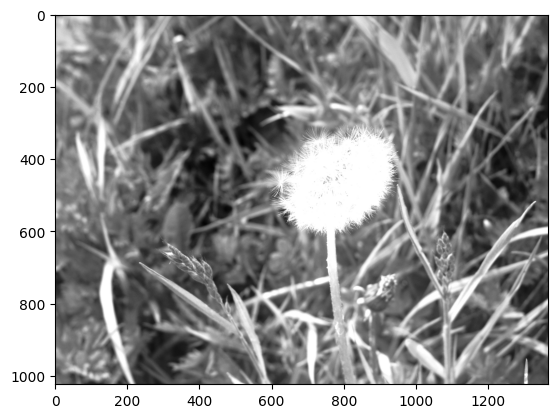

In [ ]:
# They can be visualized by turning each image into an array
plt.imshow(np.asarray(nwb.stimulus['natural_images']['0']), cmap='Greys_r')

In [ ]:
# Every table in `events`, with its shape and columns.
for table_name in (nwb.events or {}):
    table = nwb.events[table_name].to_dataframe()
    print(f'events[{table_name!r}]: {table.shape}')
    print('   ', list(table.columns))
    print()

In [ ]:
# What are the event types?
# Substitute the name of the events table your dataset actually has.

# This dataset has no events container -- the list printed above was empty. The
# mouse views passively, so nothing is licked, rewarded, or reported. Every
# discrete event time in this session is a stimulus presentation, and those live
# in intervals['stimulus_table'].
nwb.intervals['stimulus_table'].to_dataframe().stim_name.unique()

array(['drifting_gratings_full', 'drifting_gratings_windowed',
       'locally_sparse_noise', 'spontaneous', 'natural_images_12',
       'natural_movie', 'natural_images'], dtype=object)

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Extract neural activity. Do you have ephys units or ophys ROIs? 
Are there multiple activity types (e.g. dFF and deconvolved events) or just one? 
What do the timestamps look like? Is there more than one set of timestamps (e.g. one per plane)?

</div>

In [ ]:
# The processing module is itself a container - what containers are in processing?
# This is where processed data associated with neural activity or behavior live
for module_name in nwb.processing:
    print(f'{module_name}:', list(nwb.processing[module_name].data_interfaces.keys()))

behavior: ['running_speed', 'eye_tracking']
plane-0: ['demixed', 'dff', 'events', 'image_segmentation', 'images', 'neuropil_corrected', 'neuropil_fluorescence', 'raw']
plane-1: ['demixed', 'dff', 'events', 'image_segmentation', 'images', 'neuropil_corrected', 'neuropil_fluorescence', 'raw']
plane-2: ['demixed', 'dff', 'events', 'image_segmentation', 'images', 'neuropil_corrected', 'neuropil_fluorescence', 'raw']
plane-3: ['demixed', 'dff', 'events', 'image_segmentation', 'images', 'neuropil_corrected', 'neuropil_fluorescence', 'raw']
plane-4: ['demixed', 'dff', 'events', 'image_segmentation', 'images', 'neuropil_corrected', 'neuropil_fluorescence', 'raw']
plane-5: ['demixed', 'dff', 'events', 'image_segmentation', 'images', 'neuropil_corrected', 'neuropil_fluorescence', 'raw']


In [ ]:
# What is available in each neural activity related container within processing?
# This is where the different representations of the neural signal live (raw, dff, events, ...).
# Pick one container and list what it holds.

# Six planes were imaged at different depths in one cortical column, and each is
# its own processing module. Work with ONE plane: the planes are imaged in
# sequence, so each has its own timestamps (checked further down).
plane = 'plane-1'
print(list(nwb.processing[plane].data_interfaces))

['demixed', 'dff', 'events', 'image_segmentation', 'images', 'neuropil_corrected', 'neuropil_fluorescence', 'raw']


In [ ]:
# Does your dataset offer more than one representation of the neural activity
# for this plane or probe? List what is available.

# Two representations of the SAME ROIs sit side by side in this plane:
#   dff    -- continuous dF/F, one value per frame per ROI
#   events -- deconvolved event magnitude, an estimate of when the cell fired
dff_series = nwb.processing[plane]['dff']
deconvolved_series = nwb.processing[plane]['events']

print('dff   :', np.shape(dff_series.data))
print('events:', np.shape(deconvolved_series.data))

dff   : (22030, 40)
events: (22030, 40)


In [ ]:
# Find the neural activity in this file and extract the relevant data
# How is it formatted? What other information is available about cell activity?
# If your dataset has multiple planes or probes, start with one.

# (n_frames, n_rois) for this plane only -- the other five planes hold their own
# ROIs, and nothing in the file stitches them into one matrix for you.
dff = np.asarray(dff_series.data[:])

print('dff shape (nframes, nrois):', dff.shape)
print('planes available:', [module for module in nwb.processing if module.startswith('plane')])

dff shape (nframes, nrois): (22030, 40)
planes available: ['plane-0', 'plane-1', 'plane-2', 'plane-3', 'plane-4', 'plane-5']


In [ ]:
# Load the second representation (deconvolved events, spike estimates).
# Does it share the first one's shape and timestamps? What fraction of it is
# exactly zero, and why might that be?

deconvolved_events = np.asarray(deconvolved_series.data[:])

print('same shape as dff:', deconvolved_events.shape == dff.shape)
print('same timestamps  :', np.array_equal(np.asarray(deconvolved_series.timestamps[:]),
                                           np.asarray(dff_series.timestamps[:])))
print(f'fraction exactly zero -- dff {np.mean(dff == 0):.3f}, '
      f'events {np.mean(deconvolved_events == 0):.3f}')

# The deconvolution returns a magnitude only where it infers a transient, so most
# samples are exact zeros. That sparsity is what the deconvolution is for.

same shape as dff: True
same timestamps  : True
fraction exactly zero -- dff 0.046, events 0.968


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Is your dataset continuous or spiking?</b> This is the first fork in the road, and it
changes what "activity" even means.

<b>Continuous</b> (calcium imaging, LFP): represented as a `(n_timepoints, n_cells)` array, with values for every timepoint. Find it and you are done.

<b>Spiking</b> (Neuropixels, sorted electrophysiology): Each unit carries its
own list of spike times, usually in a `units` table. If your analysis requires a continuous spike rate, 
you must <b>bin</b> the spike times yourself &mdash;
choose a bin width, count spikes per bin, divide by the width to get a rate in spikes/s. 

Two decisions come with spiking data, and neither has a default:

- <b>Which units.</b> Spike sorting produces more units than you should analyze. There will be
  quality-control columns (`is_qc_pass`, `firing_rate`, `presence_ratio`, `snr`) and often an
  anatomical label. Select on them explicitly and say what you selected &mdash; a session can drop
  from thousands of units to dozens, and the ones you drop change your answer.
- <b>Bin width.</b> Too wide blurs the response; too narrow leaves mostly-empty bins and noisy
  single-trial estimates. Try a few and see how much your answer moves.

<pre>
bin_width = 0.010                                    # seconds -- your decision
edges = np.arange(0, t_end + bin_width, bin_width)
counts, _ = np.histogram(one_unit_spike_times, bins=edges)
rate = counts / bin_width                            # spikes/s
bin_centers = edges[:-1] + bin_width / 2
</pre>

Sparse binned spikes behave like a deconvolved calcium trace: sharper in time, and noisy per
trial.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Other things to consider.</b>

<b>Lazy loading.</b> NWB data objects do not load until you index them. That is what lets you open a
50&nbsp;GB file instantly, but it means `data.std()` may fail where `np.std(data)` works. Convert
with `np.asarray()` once you know the array is small enough to hold, or slice first.

<b>Timestamps.</b> Some datasets store an explicit `timestamps` array; others store a sampling
`rate` and a `starting_time`, and you reconstruct the times yourself. Everything downstream needs
real times in seconds, so check which you have &mdash; `series.timestamps` is `None` when the file
uses a rate.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Get the timestamps for your neural signal. What is the acquisition rate? 

If there are multiple imaging planes, check whether they all have the same timestamps.

</div>

In [ ]:
# Where are the timestamps located? What is the acquisition rate?
# Note that some datasets store a rate instead of a timestamps array.

# This file stores an explicit timestamps array on the series, one per frame.
plane_timestamps = np.asarray(dff_series.timestamps[:])

print('timestamps shape:', plane_timestamps.shape)
print(f'frame rate      : {1 / np.median(np.diff(plane_timestamps)):.2f} Hz')
print(f'session duration: {plane_timestamps[-1] / 60:.1f} min')

timestamps shape: (22030,)
frame rate      : 6.20 Hz
session duration: 59.2 min


In [ ]:
# If there are multiple containers within processing, do they share timestamps?
# Compare the first timestamp of two containers. If they differ, why might that be,
# and what would go wrong if you used one container's timestamps with another's data?

# The six planes are imaged in SEQUENCE at different depths, so each one has its
# own frame times. Pairing one plane's timestamps with another plane's data would
# misalign every window by up to a frame interval -- about 160 ms here, which is
# longer than most of the responses in this notebook.
other_plane_timestamps = np.asarray(nwb.processing['plane-2']['dff'].timestamps[:])

print(f'{plane} starts at {plane_timestamps[0]:.4f} s')
print(f'plane-2 starts at {other_plane_timestamps[0]:.4f} s')
print(f'offset: {1000 * (other_plane_timestamps[0] - plane_timestamps[0]):.1f} ms')

plane-1 starts at 0.1016 s
plane-2 starts at 0.1287 s
offset: 27.2 ms


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Quality control: which cells or units belong in the analysis?</h3>

Segmentation and spike sorting are automated, and both over-produce. An ophys plane contains ROIs the
classifier thinks are not cell bodies; a sorted probe contains units that drift, that are barely
above noise, or that are two neurons merged. <b>The activity matrix you just loaded usually contains
all of them.</b>

Pipelines record their own verdicts. For imaging they live on the ROI table beside the masks; for
electrophysiology, on the units table. The columns differ by pipeline and by dataset &mdash; boolean
flags, continuous probabilities, morphology metrics, contamination estimates &mdash; so there is no
list to memorise. Print the columns and see what your dataset offers.

Filtering is not automatically the right move, and the criteria are yours to justify. But
<b>inheriting the unfiltered set by default is a decision you made without noticing</b>, and it is the
kind that never appears in a methods section.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Does your dataset carry per-cell or per-unit quality metrics? Report what the
columns are, how many entries each flag would exclude, and whether the activity matrix is already
filtered or contains everything.

Then decide. Whatever you choose, **state the criterion and the count you dropped** &mdash; that
sentence belongs in your methods.

</div>

In [ ]:
# Find the per-cell quality table for your dataset and print its scalar columns:
# which are flags, which are continuous scores, and what each would exclude.

segmentation = nwb.processing[plane]['image_segmentation']
print('tables available:', list(segmentation.plane_segmentations.keys()))

roi_table = segmentation.plane_segmentations['roi_table'].to_dataframe()
print('roi_table:', roi_table.shape)
print('is_soma is a flag :', int(roi_table.is_soma.sum()), 'True of', len(roi_table))
print('pika_roi_confidence is continuous:',
      f'{roi_table.pika_roi_confidence.min():.3f} to {roi_table.pika_roi_confidence.max():.3f}')

roi_table.head()

tables available: ['roi_table']
roi_table: (40, 8)
is_soma is a flag : 40 True of 40
pika_roi_confidence is continuous: 0.728 to 0.918


,column,volume,plane,roi,pika_roi_id,pika_roi_confidence,is_soma,pixel_mask
id,,,,,,,,
0,2,1,1,0,774393007_0000,0.917007,True,"[[123, 428, 1.0], [124, 428, 1.0], [122, 429, ..."
1,2,1,1,1,774393007_0001,0.916852,True,"[[244, 94, 1.0], [245, 94, 1.0], [246, 94, 1.0..."
2,2,1,1,2,774393007_0002,0.916309,True,"[[183, 444, 1.0], [184, 444, 1.0], [185, 444, ..."
3,2,1,1,3,774393007_0003,0.915744,True,"[[414, 9, 1.0], [415, 9, 1.0], [416, 9, 1.0], ..."
4,2,1,1,4,774393007_0004,0.916208,True,"[[254, 78, 1.0], [255, 78, 1.0], [256, 78, 1.0..."


In [ ]:
# Apply your QC criterion. Check the table length matches the activity
# matrix first, apply the SAME mask to every per-cell array you loaded, and print
# how many cells you dropped.

assert len(roi_table) == dff.shape[1], 'QC table and activity matrix disagree on n cells'

# CRITERION: keep ROIs the segmentation classifier calls somata. This is the
# FILTERED release of V1DD, so that decision was already applied upstream and
# nothing is dropped here -- which is worth stating rather than assuming.
keep = np.flatnonzero(roi_table['is_soma'].values.astype(bool))
print(f'{dff.shape[1]} ROIs -> {len(keep)} pass QC ({dff.shape[1] - len(keep)} dropped on is_soma)')

# The same mask on every per-cell array, or they stop lining up with each other.
dff_after_qc = dff[:, keep]
deconvolved_events_after_qc = deconvolved_events[:, keep]
roi_table_after_qc = roi_table.iloc[keep]

print('dff after QC   :', dff_after_qc.shape)
print('events after QC:', deconvolved_events_after_qc.shape)

40 ROIs -> 40 pass QC (0 dropped on is_soma)
dff after QC   : (22030, 40)
events after QC: (22030, 40)


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Plot one cell's trace against time, as a sanity check on what you loaded.
Consider using a specific selection criterion to identify your example cell. 
 
Look at that trace for a few seconds before moving on. Is anything about it
surprising? Would you have noticed if you had skipped straight to the analysis?

</div>

In [ ]:
# Choose your cell deliberately rather than taking index 0 - how did you choose?
# Watch out for cells that are entirely NaN -- check before you index, since a
# NaN cell will silently poison anything it touches.

usable_cells = np.flatnonzero(~np.isnan(dff_after_qc).all(axis=0))
print(f'{dff_after_qc.shape[1]} cells, {len(usable_cells)} with any data')

40 cells, 40 with any data


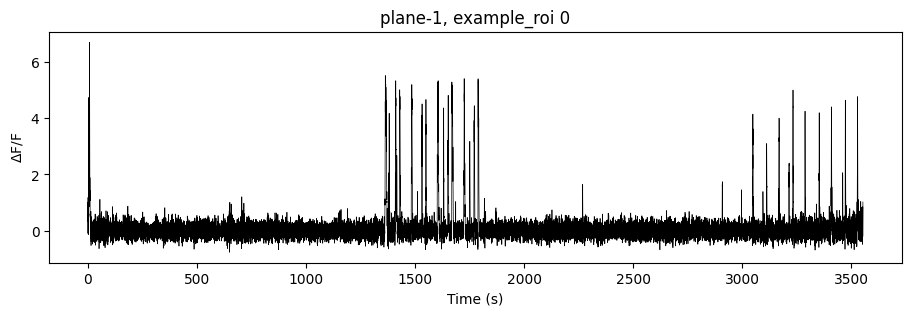

In [ ]:
# First the arbitrary choice: pick a cell by its index and plot its trace
# against time. This is effectively a random sample.

example_roi = 0

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(plane_timestamps, dff_after_qc[:, example_roi], 'k', lw=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'$\Delta$F/F')
ax.set_title(f'{plane}, example_roi {example_roi}')
plt.show()

example_roi 3 | 20 of 40 cells in the stable half


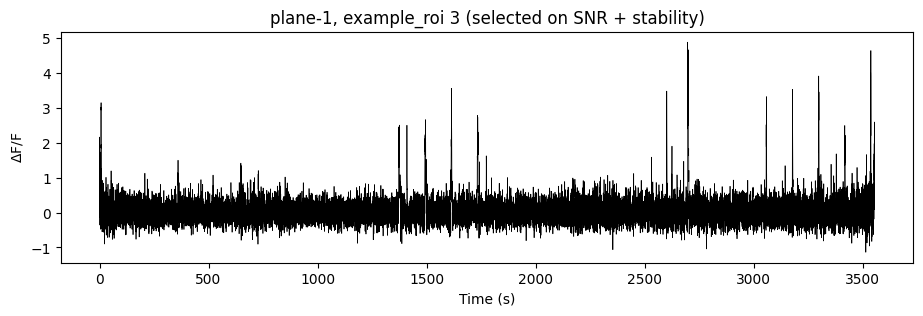

In [ ]:
# Now choose deliberately. Come up with a selection rule -- for example the
# highest signal-to-noise, or the most stable baseline across the session --
# and say what it is. Plot that cell the same way and compare.

# SELECTION RULE: the best signal-to-noise among the more stable half of the
# cells. A cell can have a high ratio because it is reliably active, or because
# its baseline wanders across the hour, so block means separate the two.
snr = (np.percentile(dff_after_qc[:, usable_cells], 99, axis=0)
       / np.std(dff_after_qc[:, usable_cells], axis=0))
blocks = np.array_split(np.arange(len(plane_timestamps)), 8)
block_means = np.array([dff_after_qc[block][:, usable_cells].mean(axis=0) for block in blocks])
instability = block_means.std(axis=0) / dff_after_qc[:, usable_cells].std(axis=0)

stable = usable_cells[instability <= np.median(instability)]
example_roi = int(stable[np.argmax(snr[np.isin(usable_cells, stable)])])
print(f'example_roi {example_roi} | {len(stable)} of {len(usable_cells)} cells in the stable half')

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(plane_timestamps, dff_after_qc[:, example_roi], 'k', lw=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'$\Delta$F/F')
ax.set_title(f'{plane}, example_roi {example_roi} (selected on SNR + stability)')
plt.show()

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Find any other information needed to reproduce your classmate's plot. 
Is it showing task epochs? Stimulus presentations? 
Is there any behavioral information like reward times or running speed? 
Where do these pieces of data live in this dataset's NWB file structure?

</div>

In [ ]:
# Is there an additional timeseries shown? Which container is it in?
# Which tables contain the relevant conditions shown on the plot?

# Running speed is in the behavior processing module, on its own clock.
running_series = nwb.processing['behavior']['running_speed']
running_speed = np.asarray(running_series.data[:])
running_timestamps = np.asarray(running_series.timestamps[:])
print(f'running_speed: {running_speed.shape} at '
      f'{1 / np.median(np.diff(running_timestamps)):.1f} Hz -- a different clock from the '
      f'{1 / np.median(np.diff(plane_timestamps)):.1f} Hz imaging')

# Both stimulus tables are in intervals: one row per presentation, and one row
# per block of a given stimulus type.
stimulus_table = nwb.intervals['stimulus_table'].to_dataframe()
stimulus_blocks = nwb.intervals['epochs'].to_dataframe()
print('stimulus_table:', stimulus_table.shape, '| stimulus_blocks:', stimulus_blocks.shape)

stimulus_blocks.head()

running_speed: (209040,) at 60.0 Hz -- a different clock from the 6.2 Hz imaging
stimulus_table: (33214, 12) | stimulus_blocks: (11, 4)


,stim_name,start_time,stop_time,duration
id,,,,
0,drifting_gratings_full,52.851639,340.074066,287.222412
1,drifting_gratings_windowed,343.093262,630.315857,287.222595
2,locally_sparse_noise,633.335022,873.551819,240.216797
3,spontaneous,874.536011,1174.769409,300.233398
4,natural_images_12,1177.788696,1329.898682,152.109985


---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 2: Reproduce the figure, and interrogate what it shows</h1>

You have your classmate's figure. You do not have their code, and you may not have a caption either.

<b>Before you write anything, write down what you think the figure shows.</b> One or two sentences,
in your notebook, as a claim someone could disagree with: <i>"activity is higher during X than during
Y"</i>, <i>"the response is larger on this trial type"</i>, <i>"these two signals rise together."</i>

Two reasons this comes first. It commits you to an interpretation before the data can talk you into
one &mdash; and it converts a picture into something you can actually test. A figure cannot be right
or wrong. A claim can.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Write your claim about the figure you picked, in the cell below, before you
write any code.

Be specific enough to be wrong. "There is neural activity" is not a claim; "population activity is
higher in the second half of the session" is.

</div>

_Your claim:_

The example figure is a session overview: running speed and population mean dF/F for one
imaging plane across the whole session, with the stimulus blocks shaded behind them. The
claim it suggests is

> *"Population activity in this plane is higher during the natural-image blocks than during
> the spontaneous gray-screen block."*

That is specific enough to be wrong: it names the two things being compared and asserts a
direction. It is also already suspicious, because the blocks differ in more than their
stimulus &mdash; they differ in duration, in when they occur in the hour, and in how much
the mouse was running. The epoch table below computes those alongside the activity so the
confound is visible rather than assumed away.


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Now replicate it</h3>

Get the pieces the figure needs and plot them. 

As you do this, consider the following: 
* What are the decisions that go into making this figure? 
* What pieces of information are present? Are they timeseries, events, epochs? 
* Can you tell how it was filtered, if at all? 
* Are there pieces of data you would have included but they did not?
* How do the decisions made during data visualization influence your understanding of the data?


</div>

In [ ]:
# Let's save our activity traces and timestamps with generalizeable names to use in the rest of the notebook

# =====================================================================
# FILL IN FOR YOUR DATASET
# =====================================================================
activity = dff_after_qc          # (n_timepoints, n_cells)
timestamps = plane_timestamps    # (n_timepoints,) seconds
events = stimulus_table          # one row per stimulus presentation / trial

# A second activity representation, if your dataset has one (deconvolved
# events, spike estimates). Set to None if it does not.
# NOTE: this must carry the same QC mask as `activity`.
activity_events = deconvolved_events_after_qc
second_signal_label = 'deconvolved event magnitude'   # what activity_events holds; None if unused
# =====================================================================

print('activity:', activity.shape, '| events:', events.shape)
print('second representation:', activity_events.shape)

activity: (22030, 40) | events: (33214, 12)
second representation: (22030, 40)


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Plot the same data features that your classmate found in this dataset. 

Do you need to transform the neural activity data in some way?  
Do you need to convert to spike rate or average across the population?  
Which neurons are included? What time period is the plot showing?

Once youve built the plot - What is going on in this session? 
</div>

In [ ]:
# Compute whatever your chosen figure shows, or plot the data directly.
# For a population average, the mean across cells at each timepoint.
# For running speed, a single timeseries.
# Are there discrete events? Are all available events included?

population_rate = activity.mean(axis=1)
print('activity  :', activity.shape, '(timepoints, cells)')
print('population:', population_rate.shape, '(timepoints,)')

# The blocks are INTERLEAVED in this session rather than run one after another,
# so collapsing them to one span per stimulus name gives spans that overlap.
epochs = (stimulus_blocks.groupby('stim_name')
          .agg(start_time=('start_time', 'min'), stop_time=('stop_time', 'max'))
          .sort_values('start_time'))
epochs['duration_s'] = (epochs.stop_time - epochs.start_time).round(1)
epochs

activity  : (22030, 40) (timepoints, cells)
population: (22030,) (timepoints,)


,start_time,stop_time,duration_s
stim_name,,,
drifting_gratings_full,52.851639,2990.281494,2937.4
drifting_gratings_windowed,343.093262,2700.039795,2356.9
locally_sparse_noise,633.335022,2096.453857,1463.1
spontaneous,874.536011,1174.769409,300.2
natural_images_12,1177.788696,1329.898682,152.1
natural_movie,1341.925293,3535.735840,2193.8
natural_images,2098.555664,2397.721436,299.2


In [ ]:
# Here is a helper function from the tutorial in case you need it 

def shade_epoch_blocks(epochs, ax):
    """Shade each epoch on `ax`, one color per epoch label.

    Epochs are the coarse structure of the session -- which stimulus block or
    task phase was running. Shading them behind a trace shows at a glance
    whether a change in activity lines up with a change in what was happening.
    """

    colors = dict(zip(epochs.index, plt.cm.Pastel1.colors))

    for label, row in epochs.iterrows():
        # zorder=0 keeps the shading BEHIND the data; alpha so the trace on top
        # stays readable. label= puts each epoch in the legend once.
        ax.axvspan(row.start_time, row.stop_time, color=colors[label],
                   alpha=0.5, zorder=0, label=label)

In [ ]:
# Plot the figure: one panel per data stream, sharing an x axis, with the
# epochs shaded behind them using the helper above.

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)

axes[0].plot(running_timestamps, running_speed, 'k', lw=0.4)
axes[0].set_ylabel('Running speed\n(cm/s)')
axes[0].set_title(f'Session overview, {plane}')

axes[1].plot(timestamps, population_rate, color='teal', lw=0.4)
axes[1].set_ylabel('Population mean\n' + r'$\Delta$F/F')
axes[1].set_xlabel('Time (s)')

for ax in axes:
    shade_epoch_blocks(epochs, ax)

axes[0].legend(bbox_to_anchor=(1.01, 1.0), loc='upper left', fontsize=8)
plt.show()

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**[Optional] Exercise:** Now test the claim you wrote above.

Turn your sentence into a number you can check. If it compares epochs, compute the mean in each one,
alongside how long each epoch lasted, when in the session it happened, and what the animal was doing.
If it compares something else, compute the equivalent.

Before you look: **what would make this comparison unfair?** Write your answer down first, then see
whether the table bears it out.

Is claim as supported, contradicted, or untestable with this data? 

</div>

In [ ]:
# For each epoch compute the mean activity, and alongside it the things that
# could confound the comparison: how long the epoch lasted, how many samples
# that is, when in the session it happened, and what the animal was doing.
# Build a DataFrame with one row per epoch.

rows = []
for label, row in epochs.iterrows():
    in_epoch = (timestamps >= row.start_time) & (timestamps < row.stop_time)
    in_epoch_run = (running_timestamps >= row.start_time) & (running_timestamps < row.stop_time)
    rows.append({'epoch': label,
                 'duration_s': round(row.stop_time - row.start_time, 1),
                 'n_samples': in_epoch.sum(),
                 'mid_session_min': round((row.start_time + row.stop_time) / 120, 1),
                 'mean_running': round(running_speed[in_epoch_run].mean(), 2),
                 'mean_activity': round(population_rate[in_epoch].mean(), 4)})

epoch_summary = pd.DataFrame(rows)
epoch_summary

---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 3: Align activity to event onsets</h1>

Let's go beyond the figure your classmate made. 

A session overview shows everything at once, which means it shows very little. To see a response
you need to **align** activity to the times when something happened, and look across repeats, not just the average.

This morning's tutorial averaged across presentations. Here we look at what the average hides.

Note that "something happened" need not be a visual stimulus. It might be a sound, an optogenetic pulse, a
reward, a lick, or the start of a trial. Anything with a repeatable onset time works the same way
&mdash; and the rest of this notebook says "event" rather than "stimulus" for that reason.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Identify events of interest. Check the stimulus, trials, intervals, and events tables to see what is available. 

What is happening during this session? What is the subject experiencing? Are there distinct stimuli, trial types, behavior events?

Explore the available conditions and select a specific type of event to examine further. 

</div>

In [ ]:
# STIMULUS TABLES -- what was presented. Which container holds these in your
# dataset, and what are the columns?

# One table in intervals holds every presentation of every stimulus family, with
# the parameter columns of all of them side by side -- so most columns are NaN
# for most rows.
print('stimulus_table:', stimulus_table.shape)
print('columns:', list(stimulus_table.columns))
print(stimulus_table.stim_name.value_counts().to_string())

stimulus_table.head()

In [ ]:
# TRIALS TABLES - when mice perform a task the data can be broken into distinct trials
# Does your dataset have one? How does it differ from the stimulus table?

# No trials table: the mouse is not performing a task in this session, it views
# passively. `intervals` holds only the two stimulus tables.
print('intervals:', list(nwb.intervals.keys()))

In [ ]:
# EVENTS - discrete events that happened in the session
# Note not all datasets have an events table within the events container

# No events container either. `stimulus` holds the templates -- the actual images
# and movie frames shown -- rather than any event times.
print('stimulus templates:', list(nwb.stimulus.keys()))
print('acquisition       :', list(nwb.acquisition.keys()))

In [ ]:
# INTERVALS -- time periods within a session, could be a stimulus or a trial type or a stimulus block
# Note not all datasets have an intervals table within the intervals container

# One row per block of a given stimulus type. The same stimulus name appears in
# several blocks spread through the session, which is why the collapsed spans in
# Part 2 overlap each other.
print('stimulus_blocks:', stimulus_blocks.shape)
print(stimulus_blocks.stim_name.value_counts().to_string())

stimulus_blocks.head()

In [ ]:
# Choose which table holds your events of interest, and save it to a variable
# called `events`. Set `condition_column` to the column whose value defines a
# condition, and `onset_column` to the column holding the event time.
# Check that the table you picked actually has the condition column you want --
# some datasets have a general-purpose intervals table that mixes several kinds
# of row together and lacks the per-presentation columns.

events = stimulus_table
onset_column = 'start_time'

# CONDITION COLUMN: stimulus_condition_id, the table's own identifier for one
# unique combination of stimulus parameters. It is filled in for every family,
# whereas image_index is only filled in for the natural-image blocks -- so using
# it keeps Part 3 and Part 4 talking about the same thing.
condition_column = 'stimulus_condition_id'

print('events:', events.shape)
print('condition ids in the whole table:', events[condition_column].nunique())

In [ ]:
# How many times was each chosen condition presented?
# Are there different variations on a given event type?
# How does your selection of event types and conditions influence the amount of data you have?

# Counted over the whole table the condition ids are dominated by the natural
# movie, where every frame is its own condition and nothing repeats usefully.
# Restricting to one stimulus family is what turns this into repeats.
full_field_gratings = events[events.stim_name == 'drifting_gratings_full']
print(f'{len(full_field_gratings)} full-field grating presentations, '
      f'{full_field_gratings[condition_column].nunique()} condition ids')
print(full_field_gratings[condition_column].value_counts().head().to_string())

# Some rows inside the grating block are blank sweeps: no direction, no spatial
# frequency. They are presentations, but they are not gratings.
print('\nblank sweeps in the block:', int(full_field_gratings.direction.isna().sum()))

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Are all of these events the same kind of event?</h3>

An event table usually contains rows that are **not equivalent trials**. Depending on the dataset
that might be first versus repeated presentations, rewarded versus unrewarded trials, different
stimulus families, trials the animal responded to versus ignored, blocks recorded before and after
a manipulation, or blank and omitted entries that are not events at all.

This matters before you align anything, for two reasons:

- **Response magnitude can differ several-fold between trial types.** Averaging them together dilutes
  the response toward whichever type is most numerous &mdash; which is often the weakest one.
- **Trial types differ in what else is happening.** Reward, licking, and arousal ride along with some
  trial types and not others, so a difference you attribute to the stimulus may not be about the
  stimulus.

Find the columns in your table that distinguish trial types, and count them.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Pick two conditions from your table and pull out the onset times of each. How many
repetitions are there of each one?

**Name the variables for what they hold.** By the end of this notebook you will have a dozen arrays
of aligned windows, masks, and subsets of subsets, and nothing in the code will remind you which is
which. `change_onset_times` and `repeat_onset_times` tell you their contents every time you read
them; `event_times_a` and `event_times_b` mean you have to scroll back to find out. The same goes
for indices: a cell index derived from one activity matrix no longer points at the same neuron once
you subset the cells, so re-derive it rather than carrying it forward.

</div>

In [ ]:
# Pull out the onset times of your two chosen conditions. Name each variable for
# the condition it holds, not 'a' and 'b' -- you will still be using these names
# several sections from now.

# Two conditions WITHIN one stimulus family, so the only thing differing between
# the groups is the parameter being compared. Pooling over direction is what
# gives each group enough presentations to average.
low_spatial_frequency, high_spatial_frequency = sorted(
    full_field_gratings.spatial_frequency.dropna().unique())

low_sf_onset_times = full_field_gratings.loc[
    full_field_gratings.spatial_frequency == low_spatial_frequency, onset_column].values
high_sf_onset_times = full_field_gratings.loc[
    full_field_gratings.spatial_frequency == high_spatial_frequency, onset_column].values

print(f'{low_spatial_frequency} cycles/deg : {len(low_sf_onset_times)} presentations')
print(f'{high_spatial_frequency} cycles/deg : {len(high_sf_onset_times)} presentations')

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Align the population average to
each event separately, then plot both on the same axes.

Write down your prediction first: do you expect a difference, and how large?

</div>

_Your prediction:_

Prediction: the two spatial frequencies will evoke population responses of similar size,
differing by well under a factor of two. Both are full-field drifting gratings covering the
whole screen, and the average pools over all directions, so the only thing separating the
groups is one stimulus parameter that individual V1 neurons are tuned to but the population
mean largely averages over.

Committing to "well under a factor of two" is what makes this checkable. There is a second
prediction worth writing down: at 6.2 Hz the window holds only a handful of samples, so
whatever difference appears will be coarse in time and any claim about response *latency*
is not measurable here.


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

To compare them we need to cut a window of data around each onset. Same
`align_to_event_times` helper as this morning's tutorial.

</div>

In [ ]:
# Here is the helper function from today's tutorial, with comments added so you can follow the logic

def align_to_event_times(data, timestamps, event_times, pre=0.5, post=1.5):
    """Cut a window of data around each event time.

    data        : array with time along the first axis
    timestamps  : time of each row of data, in seconds
    event_times : times to align to, in seconds
    pre, post   : seconds before and after each event

    Returns (aligned_windows, window_time_axis) where the time axis is in
    seconds relative to the event, and there is one window per usable_cells event.
    """
    # Sampling interval. Median, not mean: one gap in the recording would
    # inflate a mean and silently shrink every window.
    dt = np.median(np.diff(timestamps))

    # Convert the requested seconds into a number of samples. int() truncates,
    # so a window that is not a whole number of samples comes out slightly
    # short -- check this if you need exact window edges.
    n_pre, n_post = int(pre / dt), int(post / dt)

    aligned_windows = []
    for event_time in event_times:
        # Index of the first sample AT OR AFTER the event. side='left' returns
        # the insertion point, so timestamps[i] >= event_time always.
        #
        # Do NOT round to the nearest sample: that pulls roughly half the
        # trials one sample EARLIER than the event, which smears the onset and
        # can make a real response look like it starts before the stimulus.
        # Landing just after is honest -- the bias is one-directional and at
        # most one sample.
        i = np.searchsorted(timestamps, event_time, side='left')

        # Skip events too close to either end of the recording to fill a whole
        # window. This drops trials SILENTLY, so compare
        # aligned_windows.shape[0] against len(event_times) afterwards.
        if i - n_pre >= 0 and i + n_post <= len(timestamps):
            # Slice is n_pre + n_post samples long. Index n_pre within the
            # window is the first sample at/after the event, i.e. t = 0.
            aligned_windows.append(data[i - n_pre:i + n_post])

    # Time axis in seconds relative to the event. Starts at -n_pre*dt, which
    # can be slightly later than -pre because of the truncation above.
    window_time_axis = np.arange(-n_pre, n_post) * dt
    return np.array(aligned_windows), window_time_axis

In [ ]:
# Feed your population average timeseries and your event times into the helper function, once for each condition
# Consider what window around each event you want to look at and adjust the input parameters to the function accordingly
# How often does your event repeat? A post window longer than that runs into the next one.

presentation_duration = np.median(full_field_gratings.stop_time - full_field_gratings.start_time)
onset_intervals = np.diff(np.sort(full_field_gratings[onset_column].values))
print(f'presentation {presentation_duration:.2f} s, '
      f'blank gap {np.median(onset_intervals) - presentation_duration:.2f} s')

# A 1 s post window stays inside the presentation; the ~1 s blank after it means
# the pre-onset samples are a real baseline rather than the previous stimulus.
pre, post = 0.5, 1.0
aligned_low_sf, window_time_axis = align_to_event_times(population_rate, timestamps,
                                                       low_sf_onset_times, pre=pre, post=post)
aligned_high_sf, _ = align_to_event_times(population_rate, timestamps,
                                          high_sf_onset_times, pre=pre, post=post)

In [ ]:
# What does the output look like?
# Compare the number of windows you got back against the number of onsets you asked for. Are they the same?

print('low SF : asked for', len(low_sf_onset_times), '| got back', aligned_low_sf.shape[0])
print('high SF: asked for', len(high_sf_onset_times), '| got back', aligned_high_sf.shape[0])
print(f'window spans {window_time_axis[0]:+.2f} to {window_time_axis[-1]:+.2f} s '
      f'in {len(window_time_axis)} samples')

In [ ]:
# Take the mean across the aligned windows for each condition and plot them on the same axis. Label them accordingly.
# Make sure you understand the units of the x and y axes and label them as well.
# What exactly is on the y axis -- a rate, a fractional change, something else?

# y is dF/F averaged over cells and then over trials: a unitless fractional
# change in fluorescence, not a firing rate. At 6.2 Hz there are only a handful
# of samples in the window, which is why the traces look so coarse.
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(window_time_axis, aligned_low_sf.mean(axis=0), color='crimson', marker='o', ms=3,
        label=f'{low_spatial_frequency} cyc/deg (n={len(aligned_low_sf)})')
ax.plot(window_time_axis, aligned_high_sf.mean(axis=0), color='gray', marker='o', ms=3,
        label=f'{high_spatial_frequency} cyc/deg (n={len(aligned_high_sf)})')
ax.axvline(0, color='k', ls='--', lw=0.8)
ax.set_xlabel('Time from onset (s)')
ax.set_ylabel('Population mean ' + r'$\Delta$F/F')
ax.set_title('Two spatial frequencies')
ax.legend()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

What are some decisions you can make in how you process and plot the data that can affect your interpretation? 

Should you subtract the pre-event baseline? Or are you interested in the baseline activity level? 

What happens if you bin the data with a different window? 

</div>

In [ ]:
# A note on baseline subtraction: exclude the sample immediately before event onset from your baseline window.
# With binned or sampled data that sample can straddle the event,  including
# it puts part of the response into the baseline and shrinks what you
# measure. e.g. `window_time_axis < -bin_width` rather than `< 0`.

bin_width = np.median(np.diff(window_time_axis))
is_baseline = window_time_axis < -bin_width

print(f'sample interval {1000 * bin_width:.1f} ms')
print('baseline samples with `< -bin_width`:', is_baseline.sum())
print('baseline samples with `< 0`         :', (window_time_axis < 0).sum())

In [ ]:
# Try plotting the same two conditions with the pre-event baseline subtracted, and
# compare against the version above. Subtracting the baseline asks "how much did
# the stimulus change activity"; keeping it asks "how active was the population
# around this event". Which question do you want to answer?

mean_low_sf = aligned_low_sf.mean(axis=0)
mean_high_sf = aligned_high_sf.mean(axis=0)

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(window_time_axis, mean_low_sf - mean_low_sf[is_baseline].mean(),
        color='crimson', marker='o', ms=3, label=f'{low_spatial_frequency} cyc/deg')
ax.plot(window_time_axis, mean_high_sf - mean_high_sf[is_baseline].mean(),
        color='gray', marker='o', ms=3, label=f'{high_spatial_frequency} cyc/deg')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', ls='--', lw=0.8)
ax.set_xlabel('Time from onset (s)')
ax.set_ylabel('Baseline-subtracted ' + r'$\Delta$F/F')
ax.set_title('Same data, baseline removed')
ax.legend()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Are you looking at the right signal?</b>

Most datasets ship more than one representation of the same activity. &Delta;F/F carries the
indicator's rise and decay, so a brief response is smeared forward by hundreds of milliseconds.
Deconvolved events estimate when the cell actually fired, so they are temporally tighter but mostly
exact zeros &mdash; which makes single-trial estimates much noisier even though the trial average
looks cleaner. Spike times are discrete, and you choose the bin width yourself.

None is more correct; it depends on your question. A question about response <i>latency</i> is badly
served by &Delta;F/F, and one needing a reliable per-trial number is badly served by a sparse
signal. Pick one, say why, and if you have time run the analysis twice and compare.

</div>

In [ ]:
# If your dataset has more than one type of signal, recreate the plot above for each. Plot them side by side.
# What are the differences? How would it affect your interpretation?

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

for ax, (label, signal) in zip(axes, [(r'$\Delta$F/F', activity),
                                      (second_signal_label, activity_events)]):
    windows, t_signal = align_to_event_times(signal.mean(axis=1), timestamps,
                                             low_sf_onset_times, pre=0.5, post=1.0)
    baseline = windows[:, t_signal < -np.median(np.diff(t_signal))].mean(axis=1, keepdims=True)
    evoked = windows - baseline

    mean = evoked.mean(axis=0)
    standard_error = evoked.std(axis=0) / np.sqrt(len(evoked))
    ax.plot(t_signal, mean, 'k', marker='o', ms=3)
    ax.fill_between(t_signal, mean - standard_error, mean + standard_error,
                    color='crimson', alpha=0.3)
    ax.axvline(0, color='red', ls='--', lw=1)
    ax.set_xlabel('Time from onset (s)')
    ax.set_title(label)

axes[0].set_ylabel('Population evoked response')
plt.show()

In [ ]:
# Even if your dataset only has one signal (spike times), your choice of binning can affect the result
# Try recreating the spike times array with different bin widths and plot the average event aligned response with both versions side by side
# For continuous data, averaging adjacent samples asks the same question: how
# much does temporal resolution change the answer?

# Both representations are already binned at the frame rate, so averaging
# adjacent frames is the only coarsening available. The deconvolved events are
# the sparse signal, so a wider bin is what makes a single-trial estimate
# non-zero often enough to average.
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))

for ax, n_frames_per_bin in zip(axes, [1, 2, 4]):
    n_keep = (len(timestamps) // n_frames_per_bin) * n_frames_per_bin
    coarse = activity_events[:n_keep].reshape(-1, n_frames_per_bin, activity.shape[1]).mean(axis=1)
    coarse_timestamps = timestamps[:n_keep].reshape(-1, n_frames_per_bin).mean(axis=1)
    windows, t_coarse = align_to_event_times(coarse.mean(axis=1), coarse_timestamps,
                                             low_sf_onset_times, pre=2.0, post=1.5)
    baseline = windows[:, t_coarse < -np.median(np.diff(t_coarse))].mean(axis=1, keepdims=True)

    ax.plot(t_coarse, (windows - baseline).mean(axis=0), 'k', marker='o', ms=3)
    ax.set_xlabel('Time from onset (s)')
    ax.set_title(f'{1000 * np.median(np.diff(t_coarse)):.0f} ms bins')

axes[0].set_ylabel('Population evoked (events)')
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>What does the average hide?</h3>

Everything so far has been an average &mdash; over cells, then over trials. Averaging is what makes a
small response visible, but it also throws away the two things that make population data
interesting.

<b>Variability across cells.</b> Neurons are highly heterogeneous, and understanding that diversity
is a central goal of neuroscience. A population average of a hundred cells can look like a modest
response whether every cell responded modestly or five cells responded strongly and ninety-five did
nothing at all.

<b>Variability across trials.</b> Present the identical stimulus fifty times and no neuron gives the
same answer twice. Some of that is measurement noise, but much of it is real: arousal, running,
recent stimulus history, and whatever else the brain was doing on that particular trial.

Both are invisible in a mean trace, so the next two plots put them back &mdash; every trial of one
cell, then every cell of one condition. Part 4 then turns each kind of variability into a number.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Choose an example cell to look at, and say how you chose it.

Papers often show example cells without disclosing how they were selected. Taking the first cell in
the table is effectively a random sample; selecting the most responsive cell is a different choice
that changes your impression of the data. Either is defensible &mdash; state which you did.

</div>

In [ ]:
# Choose an example cell - it can be random, based on activity level, or based on some metric
# Write down the rationale for your selection criterion
# Pick the trial type and condition you will use, and check it has enough
# repetitions for a readable raster.

# A single stimulus_condition_id has only a handful of presentations in this
# session -- too few rows to read a raster from. Pooling over direction within
# one spatial frequency gives an order of magnitude more trials, at the cost of
# mixing orientations together in the average.
raster_onset_times = low_sf_onset_times

print('presentations of the most common single condition id:',
      full_field_gratings[condition_column].value_counts().max())
print('presentations pooled over direction at',
      low_spatial_frequency, 'cycles/deg:', len(raster_onset_times))

In [ ]:
# Now apply your selection rule to find the example cell. If you select on
# responsiveness, note the choice is deliberately biased -- it guarantees the
# example looks responsive and tells you nothing about the typical cell.
# Print your cell's score alongside the median across cells.

# SELECTION RULE: the most stimulus-modulated cell -- mean evoked response
# divided by its standard deviation across trials.
windows, t_window = align_to_event_times(activity, timestamps, raster_onset_times,
                                         pre=0.5, post=1.0)
bin_width = np.median(np.diff(t_window))
evoked = (windows[:, t_window >= 0].mean(axis=1)
          - windows[:, t_window < -bin_width].mean(axis=1))
modulation = evoked.mean(axis=0) / evoked.std(axis=0)
example_roi = int(np.argmax(modulation))

print('windows:', windows.shape, '(n_trials, n_timepoints, n_cells)')
print(f'most modulated cell: {example_roi} (score {modulation[example_roi]:.3f})')
print(f'median across cells: {np.median(modulation):.3f} -- the example is not typical')

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Raster vs PSTH</h3>

The event-aligned average is also called a PSTH (peri-stimulus time histogram); a plot showing every
individual trial is called a raster. Plot them together so you can see what the average discards.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** For one of your two conditions, plot the raster and the PSTH side by side. 

Using the same cell you've been working with, show the response for every trial as a heatmap (rows are trials, columns are timepoints). This is a raster.

Then plot the PSTH as the average across trials with the across trial variance as errorbars. 
Compute the standard error of the mean (standard deviation across trials divided by the square root of number of trials) 
and plot errorbars using matplotlib's fill_between()

</div>

In [ ]:
# Plot the raster and the PSTH side by side: every trial as a heatmap, and
# the trial average with a measure of variability acros trials.

aligned_windows, t = align_to_event_times(
    activity[:, example_roi], timestamps, raster_onset_times, pre=pre, post=post)
mean = aligned_windows.mean(axis=0)
standard_error = aligned_windows.std(axis=0) / np.sqrt(len(aligned_windows))

# Diverging map, symmetric limits from the 98th percentile: dF/F goes both ways.
vmax = np.percentile(np.abs(aligned_windows), 98)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].imshow(aligned_windows, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax,
               extent=[t[0], t[-1], len(aligned_windows), 0])
axes[0].set_ylabel('Presentation number')
axes[0].set_title(f'cell {example_roi}: every trial')

axes[1].plot(t, mean, 'k', lw=2, marker='o', ms=3)
axes[1].fill_between(t, mean - standard_error, mean + standard_error, color='crimson', alpha=0.3)
axes[1].set_ylabel(r'$\Delta$F/F')
axes[1].set_title(f'Mean $\\pm$ SEM (n = {len(aligned_windows)})')

for ax in axes:
    ax.axvline(0, color='k', ls='--', lw=1)
    ax.set_xlabel('Time from onset (s)')
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>PSTH across cells</h3>

We have now seen average differences across conditions on average, variability across trials for one cell - how about variability across cells for one condition?

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Now compute the average response for every cell and plot the result as a heatmap, sorted by
response magnitude. How many cells respond?

</div>

In [ ]:
# Build an array of (n_cells, n_timepoints) where the value for each cell is the condition mean
# Plot the response array as a heatmap, sorted by response magnitude.

responses_per_cell = []
for roi in range(activity.shape[1]):
    windows_roi, t = align_to_event_times(activity[:, roi], timestamps,
                                          raster_onset_times, pre=pre, post=post)
    responses_per_cell.append(windows_roi.mean(axis=0))

responses_per_cell = np.array(responses_per_cell)
order = np.argsort(responses_per_cell.mean(axis=1))[::-1]
vmax = np.percentile(np.abs(responses_per_cell), 98)

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(responses_per_cell[order], aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax,
               extent=[t[0], t[-1], len(responses_per_cell), 0])
ax.axvline(0, color='k', ls='--', lw=1)
ax.set_xlabel('Time from onset (s)')
ax.set_ylabel('Cell (sorted by mean)')
ax.set_title('Trial-averaged traces')
plt.colorbar(im, ax=ax, label=r'$\Delta$F/F')
plt.show()

In [ ]:
# Plot it again with each cell's own pre-onset baseline subtracted, and compare the two versions.
# How does baseline subtraction influence the interpretation?
# Was this the appropriate thing to do given the stimulus or event conditions you are using?

bin_width = np.median(np.diff(t))
baseline = responses_per_cell[:, t < -bin_width].mean(axis=1, keepdims=True)
change = responses_per_cell - baseline

order = np.argsort(change[:, t >= 0].mean(axis=1))[::-1]
vmax = np.percentile(np.abs(change), 98)

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(change[order], aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax,
               extent=[t[0], t[-1], len(change), 0])
ax.axvline(0, color='k', ls='--', lw=1)
ax.set_xlabel('Time from onset (s)')
ax.set_ylabel('Cell (sorted by evoked response)')
ax.set_title("Minus each cell's own pre-onset baseline")
plt.colorbar(im, ax=ax, label=r'change in $\Delta$F/F')
plt.show()

In [ ]:
# Compare the two panels. What is the sorting in the first panel actually
# ordering the cells by? How many cells increase after onset, and how many
# decrease?

# Sorting the raw panel by row mean sorts mostly by resting dF/F level, not by
# response: a cell with a high baseline sits at the top whether or not the
# grating moved it. Only after subtraction does the order mean "responded".
evoked_per_cell = change[:, t >= 0].mean(axis=1)
print('cells that increase:', int((evoked_per_cell > 0).sum()), 'of', len(evoked_per_cell))
print('cells that decrease:', int((evoked_per_cell < 0).sum()))

---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 4: Signal and noise correlations</h1>

<h3>What are signal and noise correlations, and what can they tell us?</h3>

A single neuron's average response to a stimulus is the most reported measurement in systems
neuroscience, and it is also one of the least informative things you can compute from a population
recording. Neurons do not act alone. Two cells recorded at the same time can look identical on
average and still carry different information, depending on whether they fluctuate together or
independently from trial to trial.

Correlations are how that structure gets measured, and there are two distinct kinds. They are
computed from the same data, and they answer different questions.

<b>Do two cells like the same things?</b> If both respond strongly to vertical gratings and weakly
to horizontal ones, they are tuned alike. Cells that are tuned alike often sit near each other or
belong to the same functional class, so this is a statement about functional organization.

<b>Do two cells wobble together?</b> Present the identical stimulus fifty times and no neuron gives
the same answer twice. If two cells are above their own average on the same trials, some shared
influence is moving them together.

The second one is what limits how much the population can encode. If every cell wobbles
independently, averaging across cells cancels the wobble out and the population estimate gets better
the more cells you add. If they all wobble together, averaging does not help, and a thousand neurons
carry barely more information than one.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>The math</h3>

Both are the same operation &mdash; a Pearson correlation &mdash; applied to different inputs. The
Pearson correlation between two variables $x$ and $y$ is

$$ r = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}
              {\sqrt{\sum_i (x_i - \bar{x})^2}\;\sqrt{\sum_i (y_i - \bar{y})^2}} $$

In words: **center** each variable by subtracting its mean, **multiply** the centered values
pointwise and sum, then **normalize** by each variable's spread so the result falls between -1 and
+1. `np.corrcoef` does all three steps for you.

Two consequences that matter for everything below:

- $r$ says nothing about response **size**, only whether two things move together.
- $r$ is computed over a set of paired observations, and **how many observations you have determines
  how noisy $r$ is** &mdash; but the value itself gives you no clue how many there were.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Demonstration: what does a given value of $r$ look like?</b>

Nothing below uses real data &mdash; these are <b>simulated</b> pairs of random numbers, generated
with a known correlation, so you can calibrate your eye before you trust a number computed from a
recording. Just run the cell.

</div>

In [ ]:
# SIMULATED DATA -- not from the recording. Each panel is a pair of random
# variables generated with a known correlation.
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
for ax, target_r in zip(axes, [0.0, 0.2, 0.5, 0.9]):
    simulated_x = rng.normal(size=300)
    simulated_y = target_r * simulated_x + np.sqrt(1 - target_r ** 2) * rng.normal(size=300)
    ax.scatter(simulated_x, simulated_y, s=6, alpha=0.4, color='teal')
    ax.set_title(f'simulated, r = {np.corrcoef(simulated_x, simulated_y)[0, 1]:.2f}')
    ax.set_xlabel('neuron 1')

axes[0].set_ylabel('neuron 2')
plt.show()

In [ ]:
# Mean pairwise correlations in cortex are typically 0.01-0.1 -- weaker than the
# leftmost panel. Real and consequential at the population level, but no single
# pair of neurons looks impressive.


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Correlate two neurons.

Take the full activity traces of two cells, compute the correlation between them with
`np.corrcoef`, and plot one against the other with the r value in the title.

Compare what you see against the simulated panels above.

</div>

In [ ]:
# Take the full activity traces of two cells and compute the correlation
# between them with np.corrcoef. Plot one against the other, with the
# correlation in the title.

# An arbitrary pair, not one chosen for a large r. Note the observation count:
# every imaging frame of the whole session is one point here, which is a very
# different thing from the trial-wise correlations computed later.
first_cell, second_cell = 0, 1
r_value = np.corrcoef(activity[:, first_cell], activity[:, second_cell])[0, 1]
print('n timepoints:', activity.shape[0], '| r:', round(r_value, 3))

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(activity[:, first_cell], activity[:, second_cell], s=3, alpha=0.2, color='teal')
ax.set_xlabel(f'cell {first_cell} ' + r'$\Delta$F/F')
ax.set_ylabel(f'cell {second_cell} ' + r'$\Delta$F/F')
ax.set_title(f'r = {r_value:.3f}')
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>The two kinds of correlations, and the one array they both come from</h3>

- <b>Signal correlation.</b> Do two cells respond similarly <i>across conditions</i>? Take each
  cell's average response to each condition &mdash; its tuning curve &mdash; and correlate the two
  curves. This is a statement about shared tuning, and so about functional organization.
- <b>Noise correlation.</b> When the <i>same</i> condition repeats, do the two cells fluctuate
  together around their own averages? Remove each condition's mean and correlate what is left. This
  is a statement about shared variability &mdash; <b>not</b> about connectivity, for the reasons
  above.

<b>Both come from the same array.</b> One number per cell, per trial, per condition:

<pre>
responses[condition, trial, cell]
</pre>

Every trial contributes one number for each cell &mdash; its mean activity in a window after onset,
minus its own baseline just before. Once you have that array, the two correlations are two different
ways of collapsing it.

<table>
<tr><td><b>Signal</b></td><td>average over <i>trials</i> &rarr; a tuning curve per cell &rarr;
correlate cells across <i>conditions</i></td></tr>
<tr><td><b>Noise</b></td><td>subtract each condition's mean &rarr; correlate cells across
<i>trials</i>, within one condition &rarr; average those matrices over conditions</td></tr>
</table>

Note which axis each one correlates over, because it sets how many observations you get. With 8
conditions and 400 trials per condition, a signal correlation rests on <b>8</b> paired numbers and a
noise correlation on <b>400</b>. Both render as equally convincing heatmaps.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 1: decide what conditions to compare</h3>

Everything below rests on one choice: which trials count as repeats of the same thing. Get this
wrong and every correlation downstream measures something you did not intend, with no error message.

Not every event in your table is comparable to every other. Two trials can share the same stimulus
label and still differ in what else was happening &mdash; one followed a reward and the other did
not, the animal was running through one and sitting still through the other, one was its first
exposure and one its five hundredth. Those differences do not disappear when you average; they
become part of what you are calling the response.

Pick the subset that makes a fair comparison, pick the column whose value defines the condition, and
write down why. Both choices belong in your methods.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Choose your condition column and your trial subset.

Count how many trials there are of each condition, and check whether they are balanced &mdash; the
least common condition is what limits you. Then say in a sentence which trials you are keeping and
why.

</div>

In [ ]:
# How many trials of each condition, and how balanced are they? The least
# common condition is what limits you.

# Counted within the full-field grating block, where a condition id is one
# direction crossed with one spatial frequency.
counts = full_field_gratings[condition_column].value_counts()
print(f'{len(counts)} conditions | least common {counts.min()} | most common {counts.max()} '
      f'| balance {counts.min() / counts.max():.2f}')
print(counts.head().to_string())

In [ ]:
# Restrict to the trials you consider comparable, and keep the onset times and
# the condition labels side by side -- they must stay the same length as each
# other from here on. Say why you kept the trials you kept.

# KEPT: full-field drifting gratings with a defined direction. That drops the
# blank sweeps inside the block, which carry a condition id but no grating, and
# it excludes the other families entirely -- natural images run back to back at
# ~0.3 s each, so a pre-onset baseline there is the previous image, not a blank.
comparable_trials = full_field_gratings[full_field_gratings.direction.notna()]

all_onset_times = comparable_trials[onset_column].values
labels = comparable_trials[condition_column].values

print(len(events), 'events ->', len(comparable_trials), 'comparable trials')
print('conditions:', len(np.unique(labels)),
      '| trials per condition:', pd.Series(labels).value_counts().unique())

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 2: build the response array</h3>

One number per cell per trial: mean activity in a <b>response window</b> after onset, minus mean
activity in a <b>baseline window</b> just before it.

The baseline subtraction matters. Without it each trial's "response" includes wherever the cell
happened to be sitting beforehand, and those resting levels drift together across the whole
population as the recording bleaches and the animal's arousal changes. That shared drift becomes a
large positive noise correlation with nothing to do with the stimulus.

The function below does the whole thing. Read it before you run it &mdash; it is eight lines of real
work, and every one of them is a decision you could have made differently. The two window choices
stay <i>outside</i> the function, because they are yours to set and they propagate into every number
in the rest of this notebook.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Choose your windows, then build the array.

1. Set the two windows and check how many samples each one holds. A "baseline" of one sample is not
   an average.
2. Do one cell by hand, and look at the per-trial numbers, so you know what the function is
   producing before you trust it on 60 cells.
3. Run the function and check the shape it hands back.

</div>

In [ ]:
# 1. Choose your response window and your baseline window. These are the
#    decisions -- everything downstream inherits them. Print how many SAMPLES
#    each holds: a "baseline" of one sample is not an average.

# The Part 3 plot showed the population rising for about a second after onset, so
# the response window covers that. The baseline sits in the ~1 s blank before
# onset. At 6.2 Hz these windows hold very few samples, which is the sample size
# behind every number in the correlation matrices below.
response_window = (0.0, 1.0)
baseline_window = (-0.5, 0.0)

sampling_interval = np.median(np.diff(timestamps))
print(f'sampling interval: {1000 * sampling_interval:.1f} ms')
print('response samples :', int(response_window[1] / sampling_interval))
print('baseline samples :', int(-baseline_window[0] / sampling_interval))

In [ ]:
# 2. Do one cell by hand, so you can see what the function will be doing for
#    every cell. Align, take the mean of each window, subtract, and look at the
#    per-trial numbers and their spread.

windows, window_time_axis = align_to_event_times(
    activity[:, example_roi], timestamps, all_onset_times,
    pre=-baseline_window[0], post=response_window[1])

bin_width = np.median(np.diff(window_time_axis))
is_response = window_time_axis >= 0
is_baseline = window_time_axis < -bin_width     # excludes the sample straddling onset

evoked = windows[:, is_response].mean(axis=1) - windows[:, is_baseline].mean(axis=1)

print('windows:', windows.shape, '(n_trials, n_timepoints)')
print('samples used:', int(is_response.sum()), 'response,', int(is_baseline.sum()), 'baseline')
print('first 5 trials:', np.round(evoked[:5], 4))
print(f'mean {evoked.mean():+.4f}, sd {evoked.std():.4f} across all trials')

In [ ]:
def build_response_array(activity, timestamps, onset_times, labels,
                         response_window, baseline_window):
    """One response value per condition, per trial, per cell.

    Returns
    -------
    responses : (n_conditions, n_trials, n_cells)
        Mean activity in the response window minus mean activity in the baseline
        window, for every cell on every trial, grouped by condition.
    conditions : (n_conditions,)
        The condition label of each slice along the first axis.

    Both correlations in this notebook are computed from this one array -- signal
    by averaging over trials, noise by removing each condition's mean. Which
    means every choice made below shows up in every number you report.
    """
    # ONE CELL AT A TIME. align_to_event_times expects a 1-D trace, and looping
    # keeps it obvious that nothing is mixed across cells. It also silently drops
    # any trial whose window would run off the end of the recording -- which is
    # why we re-derive the label list from the returned length further down.
    per_cell = []
    for cell in range(activity.shape[1]):
        windows, window_time_axis = align_to_event_times(
            activity[:, cell], timestamps, onset_times,
            pre=-baseline_window[0], post=response_window[1])

        # RESPONSE minus BASELINE, per trial. Subtracting each trial's OWN
        # baseline is what removes slow drift in that cell across the session; a
        # single session-wide baseline would leave the drift in the response.
        bin_width = np.median(np.diff(window_time_axis))
        is_response = window_time_axis >= 0
        is_baseline = window_time_axis < -bin_width   # drop the sample straddling onset

        per_cell.append(windows[:, is_response].mean(axis=1)
                        - windows[:, is_baseline].mean(axis=1))

    # The loop built one row per CELL; everything downstream wants trials first.
    trial_by_cell = np.array(per_cell).T
    trial_labels = np.asarray(labels)[:len(trial_by_cell)]

    # GROUP BY CONDITION. Stacking into a rectangular array needs the same trial
    # count in every condition, so each one is truncated to the length of the
    # least common. Those dropped trials are real data you are choosing not to
    # use -- if your conditions are badly unbalanced, most of your data is here.
    conditions = np.unique(trial_labels)
    n_trials = min((trial_labels == c).sum() for c in conditions)

    responses = np.stack([trial_by_cell[trial_labels == c][:n_trials]
                          for c in conditions])
    return responses, conditions

In [ ]:
# 3. Run the function. The shape is the thing to check: conditions, trials,
#    cells. Then build the index of unique cell pairs used by every summary below.

responses, conditions = build_response_array(
    activity, timestamps, all_onset_times, labels,
    response_window, baseline_window)

# Every cell pair exactly once, leaving out the diagonal, which is 1 by
# construction and would pull every average toward it.
pairs = np.triu_indices(responses.shape[2], k=1)

print('responses:', responses.shape, '(n_conditions, n_trials, n_cells)')
print('conditions:', len(conditions), '| unique cell pairs:', len(pairs[0]))

In [ ]:
# What did the truncation cost? Compare the trials kept against the trials
# available for each condition.

available = pd.Series(labels).value_counts().sort_index()
print(f'kept {responses.shape[1]} trials per condition, out of:')
print(available.to_string())
print(f'\ntotal used: {responses.shape[0] * responses.shape[1]} of {len(labels)} trials')

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 3: signal correlations</h3>

Two steps, in this order:

1. **Average over trials** &mdash; `responses.mean(axis=1)` gives `(condition, cell)`. Each column is
   one cell's tuning curve.
2. **Correlate the cells** across conditions.

Plot the tuning curves before you correlate them. A correlation matrix computed from flat,
featureless curves looks exactly as convincing as one computed from sharply tuned cells.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Compute the tuning curves, plot them, then correlate them.

`np.corrcoef` correlates **rows**, and cells are the columns of your tuning array &mdash; so
transpose. Check the output shape against your number of cells.

</div>

In [ ]:
# Average over trials -> one tuning curve per cell. Plot a few of them before
# you correlate anything: are the curves shaped, or flat?

tuning_curves = responses.mean(axis=1)
print('tuning_curves:', tuning_curves.shape, '(n_conditions, n_cells)')

fig, ax = plt.subplots(figsize=(6, 3.5))
for roi in range(tuning_curves.shape[1]):
    ax.plot(tuning_curves[:, roi], marker='o', ms=3, lw=1, alpha=0.7)
ax.axhline(0, color='k', lw=0.5)
ax.set_xticks(range(len(conditions)))
ax.set_xticklabels(conditions, rotation=90, fontsize=7)
ax.set_xlabel('stimulus_condition_id')
ax.set_ylabel('Mean evoked ' + r'$\Delta$F/F')
ax.set_title(f'Tuning curves, all {tuning_curves.shape[1]} cells')
plt.show()

In [ ]:
# Correlate the cells. .T because np.corrcoef correlates ROWS and cells are columns.
# Check the output shape against your number of cells, then plot the matrix.

signal_correlations = np.corrcoef(tuning_curves.T)

print('signal_correlations:', signal_correlations.shape, '| n_cells:', responses.shape[2])
print('observations behind each value:', responses.shape[0], 'conditions')
print(f'mean over the {len(pairs[0])} unique pairs: {signal_correlations[pairs].mean():+.3f}')

In [ ]:
# Plot the signal correlation matrix. Set the colour limit from the 98th
# percentile of the off-diagonal values -- the diagonal is 1 by construction
# and would otherwise set the scale for everything else.

vmax = np.percentile(np.abs(signal_correlations[pairs]), 98)

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(signal_correlations, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_xlabel('Cell')
ax.set_ylabel('Cell')
ax.set_title(f'Signal correlation (mean {signal_correlations[pairs].mean():+.3f})')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 4: noise correlations</h3>

Same array, collapsed the other way:

1. **Remove each condition's mean** from its own trials. What is left is everything the condition
   does not explain.
2. **Correlate the cells across trials, within one condition** &mdash; this gives one cell &times;
   cell matrix per condition.
3. **Average those matrices** over conditions.

Two things to be careful about. Subtract each condition's <b>own</b> mean, not the grand mean:
subtracting the grand mean leaves the differences between conditions in the residuals, which makes
your "noise" correlation partly a signal correlation. And note that the correlation runs over
<b>trials</b> &mdash; a single trial gives one number per cell, which is not enough to correlate
anything.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Compute the residuals, then the noise correlations.

A **residual** is what is left of a trial once you subtract the average of the trials it belongs
with. If one image evokes a mean response of 0.05 and this trial gave 0.07, the residual is +0.02
&mdash; this trial ran hotter than the condition explains. Residuals average to zero within each
condition by construction, so all the condition structure is gone and what remains is the
trial-to-trial wobble.

Check that the residuals do average to about zero within every condition. If they do not, you
subtracted the wrong mean.

</div>

In [ ]:
# Remove each condition's own mean to get the residuals. keepdims keeps the
# shape broadcastable. Check the residuals average to ~0 within every condition.

residuals = responses - responses.mean(axis=1, keepdims=True)

print('residuals:', residuals.shape)
print('largest condition mean left over:', np.abs(residuals.mean(axis=(1, 2))).max())

In [ ]:
# One correlation matrix per condition, correlating cells across that
# condition's trials. Then average the matrices, and plot the result.

per_condition = [np.corrcoef(residuals[i].T) for i in range(len(conditions))]
noise_correlations = np.mean(per_condition, axis=0)
print('noise_correlations:', noise_correlations.shape)
print('observations behind each value:', responses.shape[1], 'trials per condition')

vmax = np.percentile(np.abs(noise_correlations[pairs]), 98)

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(noise_correlations, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_xlabel('Cell')
ax.set_ylabel('Cell')
ax.set_title(f'Noise correlation (mean {noise_correlations[pairs].mean():+.3f})')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 5: put them side by side</h3>

Do cells that like the same stimuli also fluctuate together? Plot one against the other, a point per
cell pair.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Plot the signal and noise correlation heatmaps next to each other, then plot the relationship between them as a scatterplot. 
The x-axis should show the signal correlation for each pair of neurons and the y-axis should show the noise correlation for each pair. 

How strong is the relationship? What does it mean? 
</div>

In [ ]:
# Plot both matrices side by side on the SAME colour scale, so the comparison
# is fair. Pool the off-diagonal values of both to set one shared limit.

vmax = np.percentile(np.abs(np.concatenate([signal_correlations[pairs],
                                            noise_correlations[pairs]])), 98)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, matrix, name in zip(axes, [signal_correlations, noise_correlations],
                            ['Signal', 'Noise']):
    im = ax.imshow(matrix, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_xlabel('Cell')
    ax.set_title(f'{name} (mean {matrix[pairs].mean():+.3f})')
axes[0].set_ylabel('Cell')
plt.colorbar(im, ax=axes[1], fraction=0.046, label='Correlation')

rho = stats.spearmanr(signal_correlations[pairs], noise_correlations[pairs]).statistic
axes[2].scatter(signal_correlations[pairs], noise_correlations[pairs], s=12, color='teal')
axes[2].axhline(0, color='k', lw=0.5)
axes[2].axvline(0, color='k', lw=0.5)
axes[2].set_xlabel('Signal correlation')
axes[2].set_ylabel('Noise correlation')
axes[2].set_title(f'{len(pairs[0])} pairs, rho = {rho:+.3f}')
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Is this result trustworthy?</h1>

Every number so far is a point estimate with no error bar. The single most useful check: **would you
get the same answer with half the data?**

Split the trials in half at random, compute the correlations on each half separately, and correlate
the two halves' answers. Split **within each condition** so both halves see every condition.

Three outcomes, and all three are informative:

- **One high, one low** &mdash; trust the high one, and say why the other is not trustworthy.
- **Both high** &mdash; you have enough data for both; proceed.
- **Both near zero** &mdash; report that. It usually means the condition variable you chose does not
  organize these neurons' responses, however well-balanced it looked. That is a real result about
  your dataset, and it is a better README than a matrix you cannot defend.

The cell below is worked for you. Run it on your own `responses` array.

</div>

In [ ]:
# Make sure your response array is saved to a variable called "response" so the following code will run

print('responses:', responses.shape, '(n_conditions, n_trials, n_cells)')
print('conditions:', len(conditions), '| pairs:', len(pairs[0]))

In [ ]:
# Split the trials of each condition into two halves. Both halves must see
# every condition, so split WITHIN each condition rather than across all trials.
rng = np.random.default_rng(0)
n_half = responses.shape[1] // 2

shuffled = rng.permutation(responses.shape[1])
half_a = responses[:, shuffled[:n_half]]
half_b = responses[:, shuffled[n_half:2 * n_half]]

print('half_a:', half_a.shape, '| half_b:', half_b.shape)

In [ ]:
# Compute the signal correlations from each half, then ask how well the two
# halves agree over cell pairs (scipy.stats.spearmanr).
signal_a = np.corrcoef(half_a.mean(axis=1).T)
signal_b = np.corrcoef(half_b.mean(axis=1).T)

signal_reliability = stats.spearmanr(signal_a[pairs], signal_b[pairs]).statistic
print(f'signal correlation reliability: {signal_reliability:.3f}')
print(f'  from {responses.shape[0]} conditions per half')

In [ ]:
# Same for noise correlations.
noise_a = np.mean([np.corrcoef((half_a[i] - half_a[i].mean(axis=0)).T)
                   for i in range(len(conditions))], axis=0)
noise_b = np.mean([np.corrcoef((half_b[i] - half_b[i].mean(axis=0)).T)
                   for i in range(len(conditions))], axis=0)

noise_reliability = stats.spearmanr(noise_a[pairs], noise_b[pairs]).statistic
print(f'noise correlation reliability: {noise_reliability:.3f}')
print(f'  from {n_half} trials per condition per half')

In [ ]:
# HOW TO READ THE TWO NUMBERS ABOVE.
#
# Each reliability correlates two independent halves of your own data, so it
# answers "would I get this answer again?", not "is this answer big?". A result
# that does not reproduce across halves of the SAME recording will not reproduce
# in another animal.
#
# Compare each reliability against the observation count printed beside it.
# Signal correlations are computed over conditions, noise correlations over
# trials, and there are usually far more trials than conditions -- so when the
# two reliabilities differ, that gap is normally the explanation. Correlating
# two short vectors is noisy no matter how many trials went into each entry.
#
# Nothing in the heatmaps told you this. Two matrices can look equally
# structured while one is a stable feature of the population and the other is
# what noise looks like in colour.
#
# both high         -> report both, with the reliability alongside them.
# one high, one low -> report the reliable one; say the other is under-sampled,
#                      and what it would take to measure it.
# both near zero    -> report that too. Either you need more data, or your
#                      condition variable does not organize these responses.


---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Summary</h1>

<h3>The process</h3>

1. **Find out what is in the file** before analyzing it &mdash; and check that the dataset supports
   your question. Sometimes the answer is no.
2. **Plot the data after each transformation.** Single trials before averages; tuning curves before
   correlations.
3. **Name every decision.** Event subset, condition column, response window, baseline. Each is a
   fork, and each belongs in your methods.
4. **Try to break your own result.** Split the data in half and see if the answer survives.
5. **Let the dataset answer back.** If the check says your result is noise, or the dataset has no
   variable that supports your question, that is the finding. Report it rather than reaching for the
   analysis you planned to run.

<h3>Traps this notebook demonstrated</h3>

| trap | how you catch it |
| --- | --- |
| A result from few observations looks like one from many | split-half reliability |
| Analyzing units that should have been dropped | select on quality columns, and say so |
| Epoch comparisons confounded with time and behavior | check durations, order, behavior |
| An example cell chosen to look good | state your selection rule |
| Data looks absent but is stored elsewhere | look in every container first |
| An index from an earlier cell after reshaping the data | re-derive indices, never carry them |

<h3>Why this matters</h3>

You can generate an analysis faster than you can validate one. The only defense is to know your data
well enough that a wrong answer looks wrong to **you** &mdash; because it will not look wrong to the
code, and it will not look wrong on the plot.

</div>